In [1]:
import polars as pl
import json
from player_scoring_utils import (
    load_data_and_rules,
    calculate_match_points,
    aggregate_year_wise_leaderboard,
    aggregate_all_time_leaderboard,
)

In [2]:
DATA_PATH = "/Users/ravikiran.daparthy/Downloads/"
df_raw, scoring_rules = load_data_and_rules(
    f"{DATA_PATH}ipl_player_stats.csv", f"{DATA_PATH}scoring_rules.json"
)

# 2. Calculate match points (This will be blazing fast in Polars)
df_scored = calculate_match_points(df_raw, scoring_rules)

# 3. Generate Analytics
df_year_wise = aggregate_year_wise_leaderboard(df_scored)
df_all_time = aggregate_all_time_leaderboard(df_scored)



In [3]:
(
    df_year_wise
    .filter(pl.col("ipl_year") >= "2022")
    .group_by("player_name")
    .agg(
        (pl.col("total_points").sum() / pl.col("matches_played").sum()).alias("points_per_match"),
        pl.col("total_points").sum().alias("total_points"),
        pl.col("matches_played").sum().alias("matches_played"),
        pl.col("ipl_year").max().alias("last_active_year"),
        pl.col("ipl_year").n_unique().alias("active_years"),
        (pl.col("total_points").sum() / pl.col("ipl_year").n_unique()).alias("points_per_active_year"),
        # Last 3 active years points per active year
        (
            pl.col("total_points").filter(pl.col("ipl_year") >= "2023").sum()
            / pl.col("ipl_year").filter(pl.col("ipl_year") >= "2023").n_unique()
        ).alias("points_per_active_year_last_3"),
    )
    .sort(by=["points_per_active_year", "total_points"], descending=True)
    .filter(pl.col("last_active_year") == "2025")
    .filter(pl.col("matches_played") >= 10)
    [0:10]
    # .filter(pl.col("player_name").str.contains("JJ Bumrah"))
)

player_name,points_per_match,total_points,matches_played,last_active_year,active_years,points_per_active_year,points_per_active_year_last_3
str,f64,i64,u32,str,u32,f64,f64
"""JJ Bumrah""",98.025641,3823,39,"""2025""",3,1274.333333,1334.0
"""M Prasidh Krishna""",77.375,2476,32,"""2025""",2,1238.0,1280.0
"""SP Narine""",90.12963,4867,54,"""2025""",4,1216.75,1302.666667
"""Rashid Khan""",78.55,4713,60,"""2025""",4,1178.25,1085.333333
"""Priyansh Arya""",64.555556,1162,18,"""2025""",1,1162.0,1162.0
"""YS Chahal""",74.42623,4540,61,"""2025""",4,1135.0,948.333333
"""V Kohli""",72.333333,4340,60,"""2025""",4,1085.0,1280.333333
"""Shubman Gill""",70.75,4245,60,"""2025""",4,1061.25,1156.333333
"""AD Russell""",76.418182,4203,55,"""2025""",4,1050.75,935.333333


In [4]:
df_year_wise.filter(pl.col("player_name").str.contains("Prasid"))

ipl_year,player_id,player_name,matches_played,total_runs,total_wickets,balls_bowled,total_points,points_stddev,points_per_match
str,str,str,u32,i64,i64,i64,i64,f64,f64
"""2018""","""85e0cf10""","""M Prasidh Krishna""",7,1,10,168,506,85.983941,72.29
"""2019""","""85e0cf10""","""M Prasidh Krishna""",11,0,5,248,230,24.271195,20.91
"""2020/21""","""85e0cf10""","""M Prasidh Krishna""",6,2,4,105,217,80.424913,36.17
"""2021""","""85e0cf10""","""M Prasidh Krishna""",10,0,12,231,570,60.286354,57.0
"""2022""","""85e0cf10""","""M Prasidh Krishna""",17,6,19,399,1196,79.477938,70.35
"""2025""","""85e0cf10""","""M Prasidh Krishna""",15,0,25,354,1280,65.06773,85.33


In [5]:
df_scored.filter(pl.col("player_name").str.contains("Prasid"))["match_fantasy_points"].to_list()

[115,
 55,
 50,
 -10,
 115,
 40,
 -20,
 30,
 25,
 125,
 90,
 80,
 20,
 0,
 40,
 75,
 -10,
 60,
 105,
 -10,
 55,
 55,
 185,
 265,
 40,
 235,
 -10,
 -20,
 0,
 15,
 40,
 95,
 115,
 -20,
 30,
 42,
 215,
 55,
 30,
 65,
 -20,
 -10,
 65,
 31,
 195,
 40,
 -30,
 95,
 80,
 0,
 40,
 70,
 0,
 165,
 65,
 220,
 0,
 40,
 15,
 4,
 50,
 137,
 40,
 0,
 195,
 50]

In [45]:
import polars as pl
import numpy as np


# 1. KEEP THIS: Your Role Assignment
def assign_heuristic_roles(df: pl.DataFrame) -> pl.DataFrame:
    """
    Estimates player roles based on their aggregate stats.
    NOTE: In a real model, merge official roles from a separate CSV.
    """
    # Ensure balls_bowled and total_runs exist (fill nulls if necessary)
    if "balls_bowled" not in df.columns:
        df = df.with_columns(pl.lit(0).alias("balls_bowled"))
    if "total_runs" not in df.columns:
        df = df.with_columns(pl.lit(0).alias("total_runs"))

    return df.with_columns(
        [
            pl.when(pl.col("balls_bowled") == 0)
            .then(pl.lit("BAT"))
            .when((pl.col("balls_bowled") > 0) & (pl.col("total_runs") < 50))
            .then(pl.lit("BOWL"))
            .when((pl.col("balls_bowled") > 60) & (pl.col("total_runs") >= 50))
            .then(pl.lit("AR"))
            .otherwise(pl.lit("BAT"))
            .alias("role")
        ]
    )


# 2. REPLACE THE OLD MATH WITH THIS: The Simulation Pool Generator
def generate_auction_pool(
    df_match_logs: pl.DataFrame, 
    years_of_data: float = 1.0, # NEW: How many seasons does this CSV cover?
    num_teams: int = 5,
    role_requirements: dict = {"BAT": 4, "BOWL": 4, "AR": 2, "WK": 1}
) -> list:
    
    # 1. Aggregate Match Logs (Shift from MEAN to SUM)
    df_stats = df_match_logs.group_by(["player_name"]).agg(
        [
            # THE FIX: Sum total points instead of averaging them
            pl.col("match_fantasy_points").sum().alias("total_historical_points"),
            pl.col("match_fantasy_points").std().alias("std_dev_per_match"),
            # Use n_unique just in case your CSV has multiple rows per match for a player
            pl.col("match_id").n_unique().alias("matches_played"),
            pl.col("ipl_year").n_unique().alias("seasons_played"),
        ]
    )
    
    # Filter out players with virtually no data (e.g., played 1-2 games ever)
    # This prevents math errors on standard deviations.
    df_stats = df_stats.filter(pl.col('matches_played') >= 3)
    
    # 2. Assign Roles
    df_stats = assign_heuristic_roles(df_stats)
    
    # 3. Calculate Cumulative Projections & Adjusted Risk
    df_proj = df_stats.with_columns(
        [
            # THE FIX: Projected points is just their total points annualized.
            # If they played 3 games and scored 150 total points last year,
            # their projection for next year is exactly 150 points.
            (pl.col("total_historical_points") / pl.col("seasons_played"))
            .round(1)
            .alias("projected_points"),
            # Expected matches next year is their historical appearance rate
            (pl.col("matches_played") / pl.col("seasons_played")).alias(
                "expected_matches"
            ),
        ]
    )
    
    # Scale Standard Deviation based on their specific Expected Matches
    df_proj = df_proj.with_columns([
        (pl.col('std_dev_per_match') * np.sqrt(pl.col('expected_matches'))).round(1).alias('std_dev')
    ])
    df_proj = df_proj.with_columns(pl.col('std_dev').fill_null(50.0)) # Safe fallback
    
    # 4. Calculate Positional Replacement Level (VORP)
    replacement_levels = {}
    for role, req in role_requirements.items():
        depth = num_teams * req
        role_df = df_proj.filter(pl.col('role') == role).sort('projected_points', descending=True)
        
        if len(role_df) > depth:
            replacement_levels[role] = role_df['projected_points'][depth]
        else:
            replacement_levels[role] = 50.0 # Adjusted lower since cumulative points are lower than PPM projections
            
    df_rep = pl.DataFrame({
        "role": list(replacement_levels.keys()), 
        "rep_level": list(replacement_levels.values())
    })
    
    df_proj = df_proj.join(df_rep, on='role', how='left')
    
    # 5. Final VORP Calculation
    df_final = df_proj.with_columns([
        pl.when(pl.col('projected_points') > pl.col('rep_level'))
          .then(pl.col('projected_points') - pl.col('rep_level'))
          .otherwise(0.0)
          .alias('vorp')
    ])
    
    df_final = df_final.select([
        'player_name', 'role', 'projected_points', 'vorp', 'std_dev'
    ]).sort('projected_points', descending=True)
    
    return df_final.to_dicts()


# --- EXECUTION SNIPPET ---

# 1. Generate the Draft Pool
# Adjust num_teams and role_requirements to perfectly match your league settings
match_data_for_pool = df_scored.filter(
    pl.col("ipl_year") >= "2022"
)
# Filter only the players who are active in 2025 (or your next season) to ensure relevance
active_players = df_year_wise.group_by("player_name").agg(
    pl.col("ipl_year").max().alias("last_active_year")
).filter(pl.col("last_active_year") == "2025")
match_data_for_pool = match_data_for_pool.join(
    active_players.select("player_name"),
    on="player_name",
    how="inner",
)

real_players_pool = generate_auction_pool(
    df_match_logs=match_data_for_pool,
    years_of_data=1.0,
    num_teams=6,
    role_requirements={"BAT": 1, "BOWL": 1, "AR": 1, "WK": 1},
)

# 2. Preview the top 5 players to ensure VORP and Volatility look correct
print("\n--- Top 5 Players by Projected Points ---")
for p in real_players_pool[:5]:
    print(
        f"{p['player_name']:<20} | {p['role']:<4} | Pts: {p['projected_points']:<6.1f} | VORP: {p['vorp']:<6.1f} | Risk(StdDev): {p['std_dev']:.1f}"
    )

# 3. Feed directly into the Level 3 Simulator
# managers = [ApexPredator("Predator"), BarbellStrategist("Barbell") ...]
# sim = LiveIPLAuction(real_players_pool, managers)
# sim.run_auction()


--- Top 5 Players by Projected Points ---
JJ Bumrah            | BAT  | Pts: 1274.3 | VORP: 189.3  | Risk(StdDev): 404.5
M Prasidh Krishna    | BAT  | Pts: 1238.0 | VORP: 153.0  | Risk(StdDev): 289.3
SP Narine            | BAT  | Pts: 1216.8 | VORP: 131.8  | Risk(StdDev): 305.2
Rashid Khan          | BAT  | Pts: 1178.2 | VORP: 93.2   | Risk(StdDev): 295.7
Priyansh Arya        | BAT  | Pts: 1162.0 | VORP: 77.0   | Risk(StdDev): 254.0


In [24]:
match_data_for_pool.filter(pl.col("player_name").str.contains("MP Yadav"))

# df_year_wise.filter(pl.col("ipl_year") =="2025").filter(pl.col("player_name").str.contains("Yadav"))

id,match_id,ipl_year,player_id,player_name,runs_scored,balls_faced,six_count,four_count,maiden_count,runs_given,wickets_taken,dot_ball_count,bowled_lbw_wickets,catches_caught,runouts,wickets,balls_bowled,in_squad,is_out,strike_rate,overs_bowled,economy,match_fantasy_points
str,i64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64
"""1473482_b1ad996b""",1473482,"""2025""","""b1ad996b""","""MP Yadav""",0,0,0,0,0,40,2,12,1,0,0,2,24,1,0,0.0,4.0,10.0,80
"""1422139_b1ad996b""",1422139,"""2024""","""b1ad996b""","""MP Yadav""",0,0,0,0,0,13,0,2,0,0,0,0,6,1,0,0.0,1.0,13.0,0
"""1426286_b1ad996b""",1426286,"""2024""","""b1ad996b""","""MP Yadav""",0,0,0,0,0,31,1,11,1,1,0,1,19,1,0,0.0,3.166667,9.789474,60
"""1422133_b1ad996b""",1422133,"""2024""","""b1ad996b""","""MP Yadav""",0,0,0,0,0,14,3,17,1,0,0,3,24,1,0,0.0,4.0,3.5,230
"""1473491_b1ad996b""",1473491,"""2025""","""b1ad996b""","""MP Yadav""",0,0,0,0,0,60,0,6,0,2,0,0,24,1,0,0.0,4.0,15.0,0
"""1422129_b1ad996b""",1422129,"""2024""","""b1ad996b""","""MP Yadav""",0,0,0,0,0,27,3,12,0,0,0,3,24,1,0,0.0,4.0,6.75,185


In [46]:
import random


# ==========================================
# 1. BASE STRATEGY & GUARDRAILS
# ==========================================
class BiddingStrategy:
    def __init__(self, name, total_purse=120.0, min_roster=13, max_roster=15):
        self.name = name
        self.purse = total_purse
        self.min_roster_size = min_roster
        self.max_roster_size = max_roster
        self.roster = []
        self.role_counts = {"BAT": 0, "BOWL": 0, "AR": 0, "WK": 0}

    @property
    def remaining_slots(self):
        return max(0, self.max_roster_size - len(self.roster))

    @property
    def max_allowable_bid(self):
        rem_mandatory = max(0, self.min_roster_size - len(self.roster))
        if rem_mandatory == 0:
            return self.purse
        return self.purse - (0.5 * (rem_mandatory - 1))

    def buy_player(self, player, price):
        self.roster.append({"player": player, "price": price})
        self.purse -= price
        self.role_counts[player["role"]] += 1

    def apply_desperation(self, wtp, round_num, state):
        """Forces the agent to spend money if the pool is drying up."""
        total_left = max(1, state.get("total_players_left", 1))
        scarcity_ratio = self.remaining_slots / total_left

        # Scarcity Panic
        if scarcity_ratio > 0.15:
            wtp *= 1.0 + ((scarcity_ratio * 3) ** 2)

        # Mandatory Roster Panic
        if round_num > 1 and len(self.roster) < self.min_roster_size:
            avg_cash = self.purse / max(1, self.remaining_slots)
            return max(wtp, avg_cash)  # Dump average cash just to survive

        return wtp

    def check_and_execute_fire_sale(self):
        rem_mandatory = max(0, self.min_roster_size - len(self.roster))
        if rem_mandatory > 0 and self.max_allowable_bid <= 0.5 and len(self.roster) > 0:
            self.roster.sort(key=lambda x: x["price"], reverse=True)
            sold = self.roster.pop(0)
            self.purse += sold["price"] * 0.75
            self.role_counts[sold["player"]["role"]] -= 1
            return sold["player"]
        return None

    def evaluate_max_willing_bid(self, player, auction_state, round_number):
        return 0.0


# ==========================================
# 2. THE AI AGENTS
# ==========================================
class DynamicMaximizer(BiddingStrategy):
    """The Syndicate Base: Uses exponential math to proportionally allocate capital."""

    def evaluate_max_willing_bid(self, player, auction_state, round_number):
        if self.remaining_slots == 0:
            return 0.0

        avg_cash_per_slot = self.purse / self.remaining_slots
        available = auction_state["available_players_in_role"].get(player["role"], [])

        slots_needed = max(1, 4 - self.role_counts[player["role"]])
        top_alts = available[:slots_needed]
        expected_pool_pts = (
            sum(p["projected_points"] for p in top_alts) / len(top_alts)
            if top_alts
            else 100.0
        )

        point_premium = player["projected_points"] / max(1, expected_pool_pts)
        raw_wtp = avg_cash_per_slot * (point_premium**1.6)

        return min(
            self.apply_desperation(raw_wtp, round_number, auction_state),
            self.max_allowable_bid,
        )


class ApexPredator(BiddingStrategy):
    """Level 3: Hunts for 'Surplus Value' by comparing Shadow Prices."""

    def evaluate_max_willing_bid(self, player, auction_state, round_number):
        if self.remaining_slots == 0:
            return 0.0

        avg_cash_per_slot = self.purse / self.remaining_slots
        cr_per_vorp = auction_state["dynamic_cr_per_vorp"]
        expected_price = 0.5 + (player.get("vorp", 0) * cr_per_vorp)

        available = auction_state["available_players_in_role"].get(player["role"], [])
        slots_needed = max(1, 4 - self.role_counts[player["role"]])
        alternatives = available[:slots_needed]

        if not alternatives:
            return self.apply_desperation(0.5, round_number, auction_state)

        avg_alt_pts = sum(p["projected_points"] for p in alternatives) / len(
            alternatives
        )
        avg_alt_vorp = max(0, avg_alt_pts - 200)
        avg_alt_price = 0.5 + (avg_alt_vorp * cr_per_vorp)

        # Surplus Efficiency Math
        player_efficiency = player["projected_points"] / max(0.5, expected_price)
        alt_efficiency = avg_alt_pts / max(0.5, avg_alt_price)
        efficiency_ratio = player_efficiency / max(0.01, alt_efficiency)

        base_wtp = expected_price * (efficiency_ratio**1.5)
        wallet_leverage = avg_cash_per_slot / max(1.0, expected_price)
        final_wtp = base_wtp * min(2.0, max(0.8, wallet_leverage))

        return min(
            self.apply_desperation(final_wtp, round_number, auction_state),
            self.max_allowable_bid,
        )


class BarbellStrategist(DynamicMaximizer):
    """Level 3: Weaponizes risk. Demands safe floors for stars, hunts upside for scrubs."""

    def evaluate_max_willing_bid(self, player, auction_state, round_number):
        if self.remaining_slots == 0:
            return 0.0

        expected_market_price = 0.5 + (
            player.get("vorp", 0) * auction_state["dynamic_cr_per_vorp"]
        )
        cost_impact = expected_market_price / max(1.0, self.purse)

        original_pts = player["projected_points"]
        std_dev = player.get("std_dev", 50)

        if cost_impact > 0.15:
            barbell_points = original_pts - (std_dev * 1.0)  # Penalty
        elif cost_impact < 0.05:
            barbell_points = original_pts + (std_dev * 1.0)  # Reward
        else:
            barbell_points = original_pts - (std_dev * 0.25)

        player["projected_points"] = max(10, barbell_points)
        wtp = super().evaluate_max_willing_bid(player, auction_state, round_number)
        player["projected_points"] = original_pts  # Restore

        return wtp


class VampireMaximizer(DynamicMaximizer):
    """Level 3: Price Enforcer. Bluffs to drain opponents' wallets."""

    def evaluate_max_willing_bid(self, player, auction_state, round_number):
        my_true_wtp = super().evaluate_max_willing_bid(
            player, auction_state, round_number
        )

        # Simulate Opponents
        max_opp_wtp = 0.0
        for opp_name, opp_state in auction_state["agent_states"].items():
            if opp_name == self.name or opp_state["remaining_slots"] == 0:
                continue
            opp_avg_cash = opp_state["purse"] / opp_state["remaining_slots"]
            opp_max_allowable = opp_state["purse"] - (
                0.5 * (max(0, 13 - opp_state["roster_size"]) - 1)
            )
            opp_wtp = min(
                opp_avg_cash * (1.4 if player["projected_points"] > 400 else 0.8),
                opp_max_allowable,
            )
            if opp_wtp > max_opp_wtp:
                max_opp_wtp = opp_wtp

        # Price Enforcing Bluff (Push the price to 85% of their max to ruin their purse density)
        if (
            my_true_wtp < max_opp_wtp
            and my_true_wtp > (max_opp_wtp * 0.4)
            and self.remaining_slots > 3
        ):
            bluff_bid = max_opp_wtp * 0.85
            return min(bluff_bid, self.max_allowable_bid)

        return my_true_wtp


# ==========================================
# 3. THE LIVE AUCTIONEER ENGINE
# ==========================================
class LiveIPLAuction:
    def __init__(self, players_pool: list, agents: list):
        self.players_pool = players_pool
        self.agents = agents

    def run_auction(self):
        print("\n🏏 STARTING LIVE ENGLISH AUCTION 🏏")
        print("-" * 60)
        random.shuffle(self.players_pool)

        unsold_pool = []
        round_number = 1

        while self.players_pool:
            if round_number > 1:
                print(
                    f"\n--- ACCELERATED ROUND {round_number} (Unsold & Fire Sales) ---"
                )

            current_round_pool = self.players_pool.copy()
            self.players_pool = []
            players_bought = 0

            for player in current_round_pool:
                # 1. State Generation
                agent_states = {
                    a.name: {
                        "purse": a.purse,
                        "remaining_slots": a.remaining_slots,
                        "roster_size": len(a.roster),
                    }
                    for a in self.agents
                }
                total_purse = sum(a.purse for a in self.agents)
                total_mandatory = sum(
                    max(0, a.min_roster_size - len(a.roster)) for a in self.agents
                )
                avail_cash = max(0, total_purse - (total_mandatory * 0.5))

                rem_players = current_round_pool + unsold_pool
                rem_vorp = sum(p.get("vorp", 0.0) for p in rem_players)

                state = {
                    "total_players_left": len(rem_players),
                    "dynamic_cr_per_vorp": (avail_cash / rem_vorp)
                    if rem_vorp > 0
                    else 0.0,
                    "agent_states": agent_states,
                    "available_players_in_role": {
                        role: sorted(
                            [p for p in rem_players if p["role"] == role],
                            key=lambda x: x["projected_points"],
                            reverse=True,
                        )
                        for role in ["BAT", "BOWL", "AR", "WK"]
                    },
                }

                # 2. Pre-calculate true maximums with psychological noise
                active_bidders = [
                    a
                    for a in self.agents
                    if a.remaining_slots > 0 and a.max_allowable_bid >= 0.5
                ]
                wtp_dict = {}
                for a in active_bidders:
                    base_wtp = a.evaluate_max_willing_bid(player, state, round_number)
                    # The human element: Hesitation (-0.5) or Heat of the moment (+1.0)
                    noise = random.uniform(-0.5, 1.0) if base_wtp > 0.5 else 0
                    wtp_dict[a.name] = min(base_wtp + noise, a.max_allowable_bid)

                # 3. THE LIVE PADDLE-RAISING LOOP
                current_bid = 0.5
                current_winner = None
                bidding_active = any(wtp >= 0.5 for wtp in wtp_dict.values())

                if not bidding_active:
                    unsold_pool.append(player)
                    continue

                while bidding_active:
                    bidding_active = False
                    # Randomize auctioneer's eye-contact to prevent turn-order bias
                    room_order = [a for a in active_bidders if a.name != current_winner]
                    random.shuffle(room_order)

                    for agent in room_order:
                        asking_price = current_bid + 0.25 if current_winner else 0.5
                        if (
                            wtp_dict[agent.name] >= asking_price
                            and asking_price <= agent.max_allowable_bid
                        ):
                            current_bid = asking_price
                            current_winner = agent.name
                            bidding_active = True
                            break  # Auctioneer acknowledges the bid and restarts the loop

                # 4. Execute Sale
                winning_agent = next(a for a in self.agents if a.name == current_winner)
                winning_agent.buy_player(player, current_bid)
                players_bought += 1

                if current_bid > 12.0:
                    print(
                        f"💰 WAR WON: {player['player_name']} to {current_winner} for ₹{current_bid:.2f} Cr"
                    )

                # 5. Check Fire Sales
                for agent in self.agents:
                    returned_player = agent.check_and_execute_fire_sale()
                    if returned_player:
                        self.players_pool.append(returned_player)

            if players_bought == 0:
                break
            if (
                any(len(a.roster) < a.min_roster_size for a in self.agents)
                and unsold_pool
            ):
                self.players_pool.extend(unsold_pool)
                unsold_pool = []
                round_number += 1
            else:
                break
        print("\n🏁 AUCTION CONCLUDED 🏁")


# ==========================================
# 4. SCORING & EXECUTION
# ==========================================
def score_teams(agents):
    print("\n🏆 FINAL ROSTER SCORING (Top 11 Players) 🏆")
    print(
        f"{'Manager / Strategy':<25} | {'Expected Pts':<12} | {'Spent (Cr)':<10} | {'Roster'}"
    )
    print("-" * 70)

    results = []
    for agent in agents:
        top_11 = sorted(
            agent.roster, key=lambda x: x["player"]["projected_points"], reverse=True
        )[:11]
        total_points = sum(p["player"]["projected_points"] for p in top_11)
        total_spent = 120.0 - agent.purse
        results.append({"name": agent.name, "points": total_points})
        print(
            f"{agent.name:<25} | {total_points:<12.1f} | ₹{total_spent:<8.2f} | {len(agent.roster)}"
        )

    results.sort(key=lambda x: x["points"], reverse=True)
    print(f"\n🎉 WINNER: {results[0]['name']} 🎉")
    return results[0]["name"]



In [48]:
real_players_pool[:5]


[{'player_name': 'JJ Bumrah',
  'role': 'BAT',
  'projected_points': 1274.3,
  'vorp': 189.29999999999995,
  'std_dev': 404.5},
 {'player_name': 'M Prasidh Krishna',
  'role': 'BAT',
  'projected_points': 1238.0,
  'vorp': 153.0,
  'std_dev': 289.3},
 {'player_name': 'SP Narine',
  'role': 'BAT',
  'projected_points': 1216.8,
  'vorp': 131.79999999999995,
  'std_dev': 305.2},
 {'player_name': 'Rashid Khan',
  'role': 'BAT',
  'projected_points': 1178.2,
  'vorp': 93.20000000000005,
  'std_dev': 295.7},
 {'player_name': 'Priyansh Arya',
  'role': 'BAT',
  'projected_points': 1162.0,
  'vorp': 77.0,
  'std_dev': 254.0}]

In [ ]:
# # --- Prepare Player Pool for Auction ---
# auction_players = (
#     auction_board.filter(pl.col("projected_points") > 150)
#     .select(
#         [
#             "player_name",
#             "role",
#             "projected_points",
#             "vorp",
#         ]
#     )
#     .to_dicts()
# )

# auction_players

[{'player_name': 'Noor Ahmad',
  'role': 'BOWL',
  'projected_points': 1357.0,
  'vorp': 747.0},
 {'player_name': 'B Sai Sudharsan',
  'role': 'BAT',
  'projected_points': 1424.0,
  'vorp': 725.0},
 {'player_name': 'M Prasidh Krishna',
  'role': 'BOWL',
  'projected_points': 1280.0,
  'vorp': 670.0},
 {'player_name': 'SA Yadav',
  'role': 'BAT',
  'projected_points': 1367.0,
  'vorp': 668.0},
 {'player_name': 'Arshdeep Singh',
  'role': 'BOWL',
  'projected_points': 1222.0,
  'vorp': 612.0},
 {'player_name': 'JJ Bumrah',
  'role': 'BOWL',
  'projected_points': 1185.0,
  'vorp': 575.0},
 {'player_name': 'TA Boult',
  'role': 'BOWL',
  'projected_points': 1182.0,
  'vorp': 572.0},
 {'player_name': 'JR Hazlewood',
  'role': 'BOWL',
  'projected_points': 1180.0,
  'vorp': 570.0},
 {'player_name': 'V Kohli',
  'role': 'BAT',
  'projected_points': 1201.0,
  'vorp': 502.0},
 {'player_name': 'Shubman Gill',
  'role': 'BAT',
  'projected_points': 1200.0,
  'vorp': 501.0},
 {'player_name': 'SP N

In [49]:
winner_list = []
for i in range(1000):
    # Generate 120 Mock Players with accurate VORP and Standard Deviations
    # mock_players = []
    # for i in range(120):
    #     pts = random.randint(100, 800)
    #     volatility = random.randint(20, 80) if pts > 500 else random.randint(50, 200)
    #     mock_players.append(
    #         {
    #             "player_name": f"Player_{i}",
    #             "role": random.choice(["BAT", "BOWL", "AR", "WK"]),
    #             "projected_points": pts,
    #             "vorp": max(0, pts - 200),
    #             "std_dev": volatility,
    #         }
    #     )

    # Pit the Level 3 Master-Class Bots against the Level 1 Syndicate
    managers = [
        ApexPredator("The Apex Predator"),
        BarbellStrategist("The Barbell (Risk)"),
        VampireMaximizer("The Vampire (Bluffer)"),
        DynamicMaximizer("The Syndicate (Math)"),
        DynamicMaximizer("Quant Bot (Math)"),
    ]

    sim = LiveIPLAuction(real_players_pool[:100], managers)
    sim.run_auction()
    winner = score_teams(managers)
    winner_list.append(winner)



🏏 STARTING LIVE ENGLISH AUCTION 🏏
------------------------------------------------------------

🏁 AUCTION CONCLUDED 🏁

🏆 FINAL ROSTER SCORING (Top 11 Players) 🏆
Manager / Strategy        | Expected Pts | Spent (Cr) | Roster
----------------------------------------------------------------------
The Apex Predator         | 9636.4       | ₹95.75    | 15
The Barbell (Risk)        | 8006.1       | ₹52.25    | 15
The Vampire (Bluffer)     | 10403.2      | ₹86.25    | 15
The Syndicate (Math)      | 8335.8       | ₹20.25    | 15
Quant Bot (Math)          | 8091.6       | ₹60.50    | 15

🎉 WINNER: The Vampire (Bluffer) 🎉

🏏 STARTING LIVE ENGLISH AUCTION 🏏
------------------------------------------------------------

🏁 AUCTION CONCLUDED 🏁

🏆 FINAL ROSTER SCORING (Top 11 Players) 🏆
Manager / Strategy        | Expected Pts | Spent (Cr) | Roster
----------------------------------------------------------------------
The Apex Predator         | 8946.5       | ₹84.50    | 15
The Barbell (Risk)       

([0, 1, 2, 3, 4],
 [Text(0, 0, 'The Vampire (Bluffer)'),
  Text(1, 0, 'Quant Bot (Math)'),
  Text(2, 0, 'The Apex Predator'),
  Text(3, 0, 'The Barbell (Risk)'),
  Text(4, 0, 'The Syndicate (Math)')])

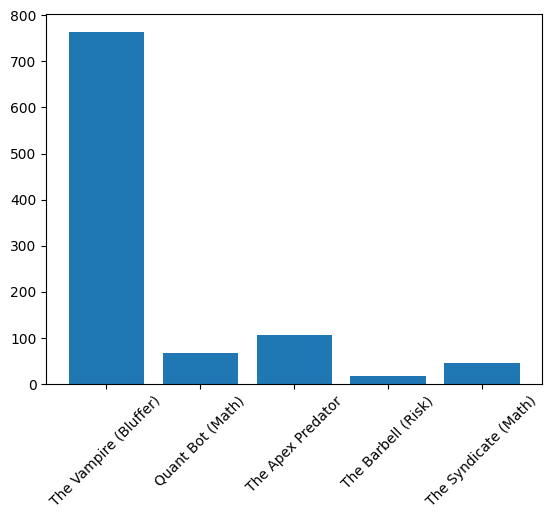

In [50]:
import matplotlib.pyplot as plt
plt.hist(winner_list, bins=np.arange(len(set(winner_list)) + 1) - 0.5, rwidth=0.8)
plt.xticks(rotation=45)
